In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import (bernoulli,binom,poisson,lognorm,powerlaw,zscore,boxcox)

import statsmodels.api as sm

In [3]:
df = pd.read_csv(r"C:\Users\solan\Downloads\spread_locator_dataset - spread_locator_dataset.csv.csv")

In [4]:
df.head()

,transaction_id,customer_id,transaction_amount,transaction_date,transaction_count,region,transaction_status
0,e98aa092-3770-4fdb-9502-5b5a6a244811,CUST2824,3821.34,2023-01-26,3,North,Fail
1,11ba6918-dba0-41e5-96cf-f5a7b95f0103,CUST1409,2781.84,2023-01-28,0,East,Fail
2,82b7654b-6eb7-4579-89a0-1a9edec0a7bb,CUST5506,4120.97,2023-01-28,0,South,Fail
3,f7166574-f400-4d53-b526-0b11f6619ddf,CUST5012,6383.78,2023-01-18,2,South,Success
4,8632fe26-b507-4068-9c68-1b2fa04fecb3,CUST4657,2651.61,2023-01-04,4,North,Success


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   transaction_id      220 non-null    object 
 1   customer_id         220 non-null    object 
 2   transaction_amount  220 non-null    float64
 3   transaction_date    220 non-null    object 
 4   transaction_count   220 non-null    int64  
 5   region              220 non-null    object 
 6   transaction_status  220 non-null    object 
dtypes: float64(1), int64(1), object(5)
memory usage: 12.2+ KB


In [6]:
df.isnull().sum()

transaction_id        0
customer_id           0
transaction_amount    0
transaction_date      0
transaction_count     0
region                0
transaction_status    0
dtype: int64

In [7]:
df.describe()

,transaction_amount,transaction_count
count,220.000000,220.000000
mean,3365.192409,2.854545
std,1985.705409,1.797189
min,804.420000,0.000000
25%,2124.205000,1.750000
50%,3077.715000,3.000000
75%,3950.737500,4.000000
max,20462.840000,9.000000


1. What is Statistical Distribution?

A statistical distribution describes how the values of a variable are spread across a dataset. It shows the frequency or probability of occurrence of different values. Statistical distributions help analysts understand patterns, variability, and trends in data.

For example, transaction amounts in an e-commerce platform may follow a normal, log-normal, or power-law distribution depending on customer purchasing behavior.

Importance:
Helps in understanding data patterns
Used in probability calculations
Helps select appropriate machine learning and statistical models
Useful in anomaly detection and forecasting

2. What is a Q-Q Plot and Why is it Used?

A Q-Q (Quantile-Quantile) Plot is a graphical method used to compare whether a dataset follows a particular statistical distribution, especially the normal distribution.

In a Q-Q plot:

If the points lie approximately on a straight line, the data is normally distributed.
If the points deviate from the line, the data is skewed or non-normal.
Uses:
Checking normality of data
Detecting skewness and outliers
Validating assumptions for statistical models

3. Difference Between Discrete and Continuous Distributions

Discrete Distribution           	        Continuous Distribution
Deals with countable values	                with measurable values
Values are separate	                        Values can take any value in a range
Example: Number of transactions	            Example: Transaction amount
Uses PMF	Uses PDF

4. What is Bernoulli Distribution?

Bernoulli Distribution is a discrete probability distribution that has only two possible outcomes:

Success (1)
Failure (0)

It is used when an experiment has only one trial.

Formula:
P(X=x)=px(1−p)1−x

Where:

p = probability of success
Example:

In this project:

Successful transaction = 1
Failed transaction = 0

5. What is Binomial Distribution?

Binomial Distribution represents the probability of obtaining a fixed number of successes in a fixed number of independent trials.

Conditions:
Fixed number of trials
Two outcomes only
Probability remains constant
Formula:
P(X=k)=(
k
n
	​

)p
k
(1−p)
n−k

Where:

n = number of trials
k = number of successes
p = probability of success
Example:

Weekly successful transactions by customers.

6. Explain Log-Normal Distribution

A Log-Normal Distribution occurs when the logarithm of a variable is normally distributed.

It is commonly used for:

Income distribution
Transaction amounts
Stock prices
Characteristics:
Positively skewed
Values cannot be negative
Long right tail

In this project, transaction amounts are suitable for log-normal modeling because high-value transactions create skewness.

7. Explain Power Law Distribution

Power Law Distribution describes situations where a small number of events have extremely large values while most events remain small.

Characteristics:
Heavy tail
Extreme values occur more frequently
Used in social networks, wealth distribution, online sales
Example:

A few customers may contribute very large transaction amounts while most customers make smaller purchases.

8. What is Box-Cox Transform?

Box-Cox Transformation is a statistical transformation technique used to reduce skewness and stabilize variance in data.

It transforms non-normal data into approximately normal data.

Benefits:
Improves model performance
Reduces skewness
Stabilizes variance
Formula:
Y(λ)=λY−1/λ
	​


9. Explain Poisson Distribution with Example

Poisson Distribution models the number of times an event occurs within a fixed interval of time or space.

Characteristics:
Discrete distribution
Events occur independently
Used for count data

Where:

λ = average number of occurrences
Example:

Number of transactions occurring per day on the e-commerce platform.

10. What is Z-score Probability?

Z-score measures how many standard deviations a value is away from the mean.

Formula:
Z=X−μ/σ
	​

Where:

X = value
μ = mean
σ = standard deviation
Uses:
Outlier detection
Probability calculations
Standardization
Example:

Finding the probability of transactions exceeding ₹5000.

11. Difference Between PDF and CDF
PDF	                                        CDF
Probability Density Function	            Cumulative Distribution Function
Shows density at a point	                Shows cumulative probability
Used in continuous distributions	        Used to calculate probability up to a value
Area under curve = probability	            Always ranges from 0 to 1

Example:
PDF shows likelihood of transaction amounts
CDF shows probability that transaction amount is less than a specific value

PART B — PRACTICAL IMPLEMENTATION

In [8]:
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

In [9]:
df['status_encoded'] = df['transaction_status'].map({
    'Success':1,
    'Fail':0
})

In [10]:
p = df['status_encoded'].mean()

print("Probability of Success:", p)

Probability of Success: 0.44545454545454544


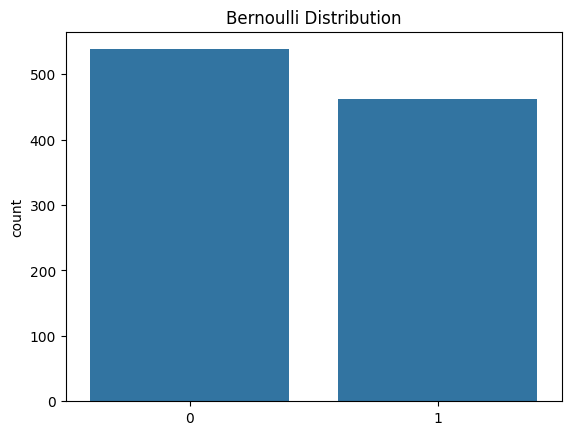

In [11]:
bernoulli_sample = bernoulli.rvs(p, size=1000)

sns.countplot(x=bernoulli_sample)

plt.title("Bernoulli Distribution")
plt.show()

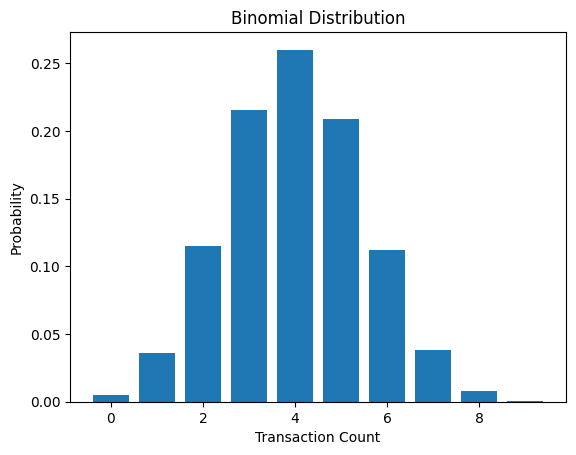

In [12]:
#Binomial Distribution
n = df['transaction_count'].max()

p = df['status_encoded'].mean()

x = np.arange(0, n+1)

binomial_probs = binom.pmf(x, n, p)

plt.bar(x, binomial_probs)

plt.title("Binomial Distribution")
plt.xlabel("Transaction Count")
plt.ylabel("Probability")

plt.show()

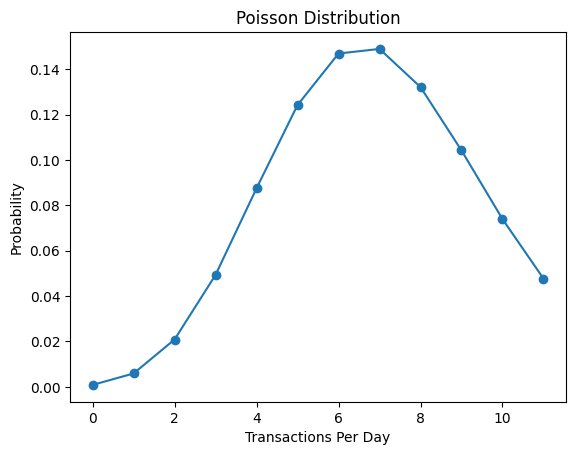

In [13]:
#Poisson Distribution
daily_transactions = df.groupby('transaction_date').size()
lam = daily_transactions.mean()

x = np.arange(0, daily_transactions.max())

poisson_probs = poisson.pmf(x, lam)

plt.plot(x, poisson_probs, marker='o')

plt.title("Poisson Distribution")
plt.xlabel("Transactions Per Day")
plt.ylabel("Probability")

plt.show()

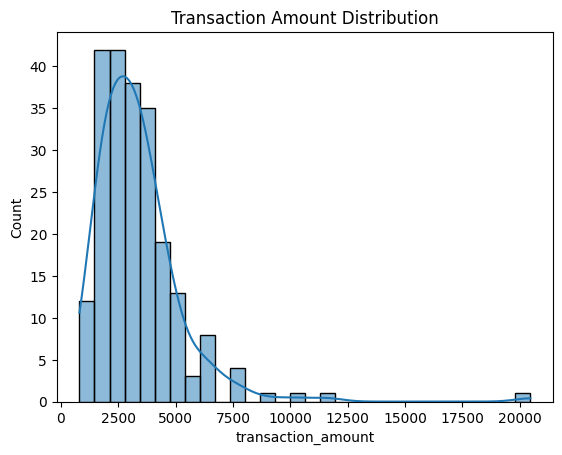

In [14]:
#Log-Normal Distribution
sns.histplot(df['transaction_amount'], kde=True)

plt.title("Transaction Amount Distribution")

plt.show()

In [16]:
#Fit Log-Normal Distribution
shape, loc, scale = lognorm.fit(df['transaction_amount'])

print(shape, loc, scale)

0.5416831487801056 333.7722748609052 2604.740667049811


In [17]:
#Power Law Distribution
params = powerlaw.fit(df['transaction_amount'])

print(params)

(np.float64(0.41232325172331613), np.float64(804.4199999999998), np.float64(19658.420000000006))


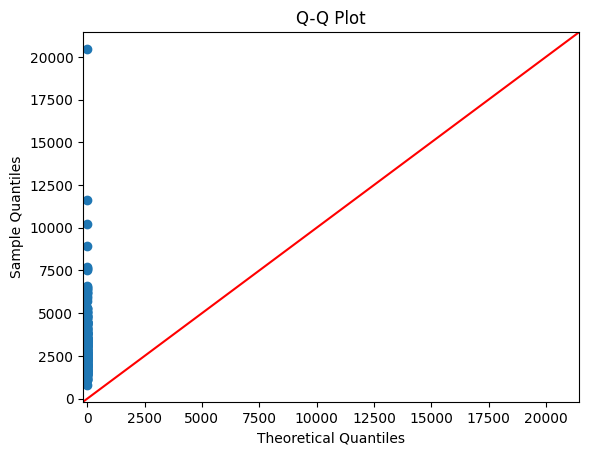

In [18]:
#Q-Q Plot
sm.qqplot(df['transaction_amount'], line='45')

plt.title("Q-Q Plot")

plt.show()

Lambda Value: -0.18083390743966327


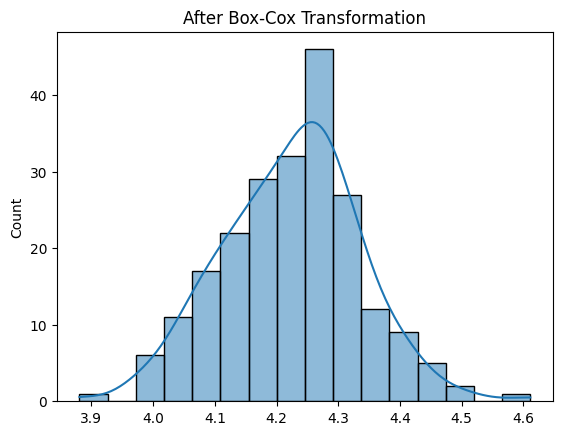

In [20]:
#Box-Cox Transformation
transformed_data, lambda_value = boxcox(df['transaction_amount'])

print("Lambda Value:", lambda_value)
#
# Visualization
sns.histplot(transformed_data, kde=True)

plt.title("After Box-Cox Transformation")

plt.show()

In [ ]:
#Z-score Calculation
df['z_score'] = zscore(df['transaction_amount'])

df[['transaction_amount', 'z_score']].head()

In [21]:
#13. Probability of Transactions Exceeding ₹5000
mean = df['transaction_amount'].mean()

std = df['transaction_amount'].std()

z = (5000 - mean) / std

probability = 1 - stats.norm.cdf(z)

print("Probability of transaction exceeding 5000:", probability)

Probability of transaction exceeding 5000: 0.20517209567554384


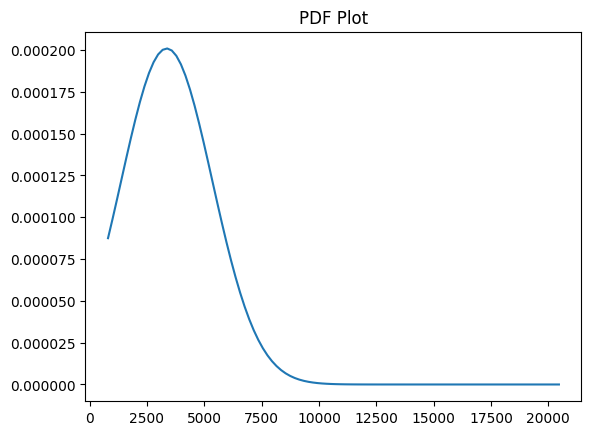

In [22]:
#14. PDF Plot
x = np.linspace(
    df['transaction_amount'].min(),
    df['transaction_amount'].max(),
    100
)

pdf = stats.norm.pdf(
    x,
    mean,
    std
)

plt.plot(x, pdf)

plt.title("PDF Plot")

plt.show()

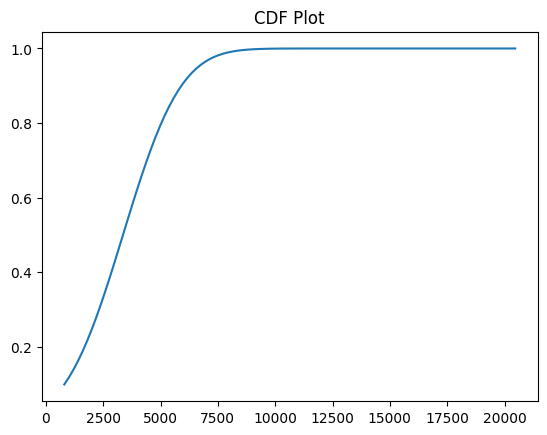

In [23]:
cdf = stats.norm.cdf(
    x,
    mean,
    std
)

plt.plot(x, cdf)

plt.title("CDF Plot")

plt.show()

16. Final Conclusion

The analysis shows that transaction amounts are positively skewed and better modeled using Log-Normal and Power Law distributions. Bernoulli and Binomial distributions successfully modeled transaction success behavior, while Poisson distribution modeled daily transaction frequency. The Q-Q plot confirmed non-normality in the original data, and Box-Cox transformation improved normality by reducing skewness. Z-score analysis helped identify probabilities and potential outliers in transaction amounts.